# NB4 — Final Comparison (Task H)

Standalone comparison notebook. Reads the shared `results.json` and each model's
cached qualitative predictions from NB1 (DeepLabV3), NB2 (SegFormer-B0), and NB3
(YOLOv26-Semantic) -- **does not retrain or reload any model**, so it runs in
seconds even after the training notebooks' sessions have long since ended.

**Before running:** attach NB1's, NB2's, and NB3's Kaggle outputs as Input data
sources to this notebook (Add Input → search your own notebooks), the same way
you'd attach any dataset. This notebook only reads files -- it has no GPU-heavy
step and does not need a GPU runtime at all.

Run this any time after all three training notebooks have finished and produced
their `results.json` + `qualitative_cache/` outputs.


In [1]:
# ── Setup: load results.json + class palette (no GPU / model libraries needed) ─
import json
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import subprocess
print(subprocess.run(['find', '/kaggle/input', '-name', 'stems.json'], capture_output=True, text=True).stdout)

# ── Merge each notebook's results.json (falls back to /kaggle/working if all three
#    happened to run in one persistent session instead of separate Kaggle sessions) ──
RESULT_SOURCES = [
    Path('/kaggle/working/results.json'),
    Path('/kaggle/input/notebooks/mohuaakter/seg-deeplabv3/results.json'),
    Path('/kaggle/input/notebooks/mohuaakter/seg-segformer-b0/results.json'),
    Path('/kaggle/input/notebooks/mohuaakter/seg-yolov26-semantic/results.json'),
]
results = {}
for p in RESULT_SOURCES:
    if p.exists():
        other = json.loads(p.read_text())
        results.update({k: v for k, v in other.items() if k not in results})

print('Models found:', list(results.keys()))
if not results:
    print(' No results.json found anywhere. Attach NB1/NB2/NB3 outputs as Input data '
          'sources to this notebook (Add Input → your notebooks) and re-run this cell.')

# ── Class palette + test_df (needed to display Image / Ground truth columns) ──
# Reuses the same split-loading approach as NB1/NB2/NB3.
SPLIT_CANDIDATES = [
    Path('/kaggle/input/datasets/mohuaakter/fruitseg30-splitted-data/FruitSeg30_processed'),
    Path('/kaggle/working/FruitSeg30_processed'),
]
SPLIT_ROOT = next((p for p in SPLIT_CANDIDATES if p.exists()), None)
if SPLIT_ROOT is None:
    print(' Could not locate FruitSeg30_processed -- attach the split-data source '
          'if you want the qualitative grid (score table/charts below will still work).')
else:
    class_dict = pd.read_csv(SPLIT_ROOT / 'class_dict.csv')
    CLASS_NAMES = class_dict['class_name'].tolist() if 'class_name' in class_dict.columns else class_dict.iloc[:, 0].tolist()
    PALETTE = np.array(class_dict[['r', 'g', 'b']].values, dtype=np.uint8) if {'r','g','b'}.issubset(class_dict.columns) else None

    rows = []
    for img_path in sorted((SPLIT_ROOT / 'test' / 'images').glob('*')):
        stem = img_path.stem
        mask_path = SPLIT_ROOT / 'test' / 'masks' / f'{stem}.png'
        if mask_path.exists():
            rows.append({'stem': stem, 'image_path': img_path, 'mask_path': mask_path})
    test_df = pd.DataFrame(rows)
    print(f'Loaded {len(test_df)} test images for the qualitative grid.')


/kaggle/input/notebooks/mohuaakter/seg-yolov26-semantic/qualitative_cache/YOLOv26-Semantic/stems.json
/kaggle/input/notebooks/mohuaakter/seg-deeplabv3/qualitative_cache/DeepLabV3-ResNet101/stems.json
/kaggle/input/notebooks/mohuaakter/seg-segformer-b0/qualitative_cache/SegFormer-B0/stems.json

Models found: ['DeepLabV3-ResNet101', 'SegFormer-B0', 'YOLOv26-Semantic']
Loaded 309 test images for the qualitative grid.


## Task H — Final Comparison (DeepLabV3 vs. SegFormer-B0 vs. YOLOv26-Semantic)

In [2]:
# ── Task H: summary table across all metrics from Task F ────────────────────
summary_rows = []
for model_name, r in results.items():
    summary_rows.append({
        'Model': model_name,
        'mIoU': r['test_mIoU'],
        'Mean Dice': r['test_mean_dice'],
        'Pixel Accuracy': r['test_pixel_accuracy'],
        'Mean Pixel Accuracy': r['test_mean_pixel_accuracy'],
        'Epochs Trained': r['config'].get('actual_epochs_trained', 'n/a'),
        'Training Time (min)': r['config'].get('total_training_time_min', 'n/a'),
    })
summary_df = pd.DataFrame(summary_rows).sort_values('mIoU', ascending=False)
print(summary_df.to_string(index=False))


              Model     mIoU  Mean Dice  Pixel Accuracy  Mean Pixel Accuracy  Epochs Trained  Training Time (min)
   YOLOv26-Semantic 0.944193   0.968966        0.858496             0.967584              80                274.3
       SegFormer-B0 0.918930   0.955337        0.962585             0.987224              65                586.4
DeepLabV3-ResNet101 0.608084   0.712282        0.871882             0.770361              50                497.6


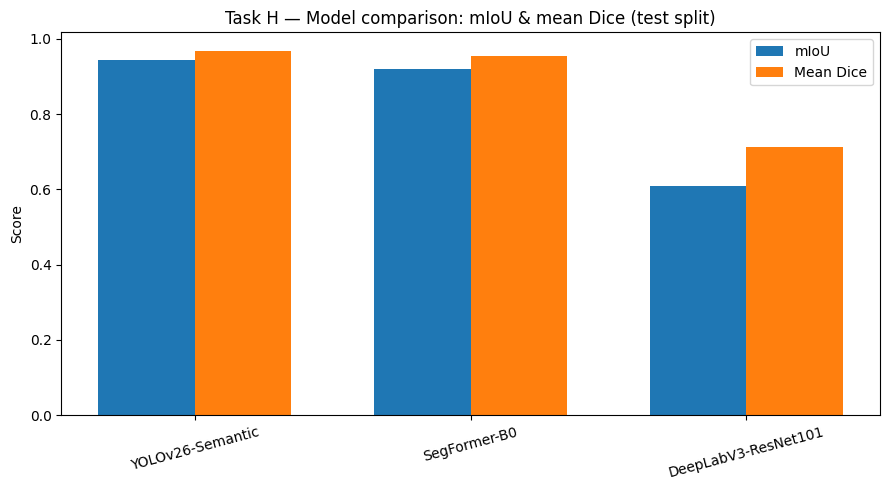

In [3]:
# ── Task H: bar chart comparing mIoU and mean Dice across the three models ──
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width/2, summary_df['mIoU'], width, label='mIoU')
ax.bar(x + width/2, summary_df['Mean Dice'], width, label='Mean Dice')
ax.set_xticks(x); ax.set_xticklabels(summary_df['Model'], rotation=15)
ax.set_ylabel('Score'); ax.set_title('Task H — Model comparison: mIoU & mean Dice (test split)')
ax.legend()
plt.tight_layout(); plt.show()


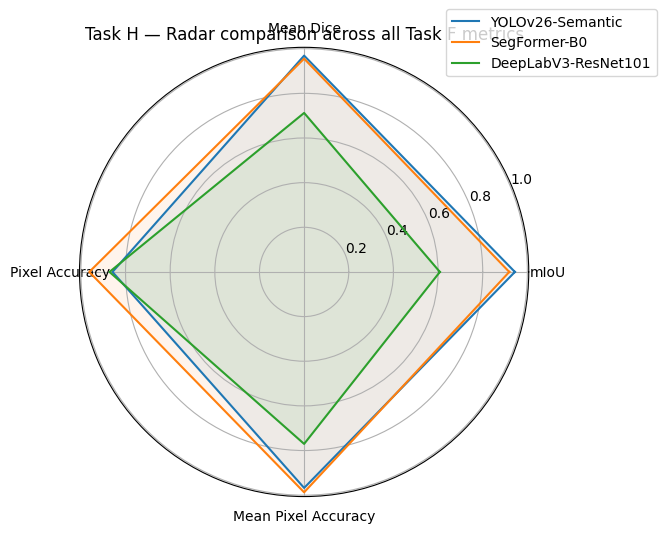

In [4]:
# ── Task H: radar chart across four metrics ──────────────────────────────────
metrics_for_radar = ['mIoU', 'Mean Dice', 'Pixel Accuracy', 'Mean Pixel Accuracy']
angles = np.linspace(0, 2 * np.pi, len(metrics_for_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
for _, row in summary_df.iterrows():
    values = [row[m] for m in metrics_for_radar]
    values += values[:1]
    ax.plot(angles, values, label=row['Model'])
    ax.fill(angles, values, alpha=0.08)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_for_radar)
ax.set_title('Task H — Radar comparison across all Task F metrics')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()


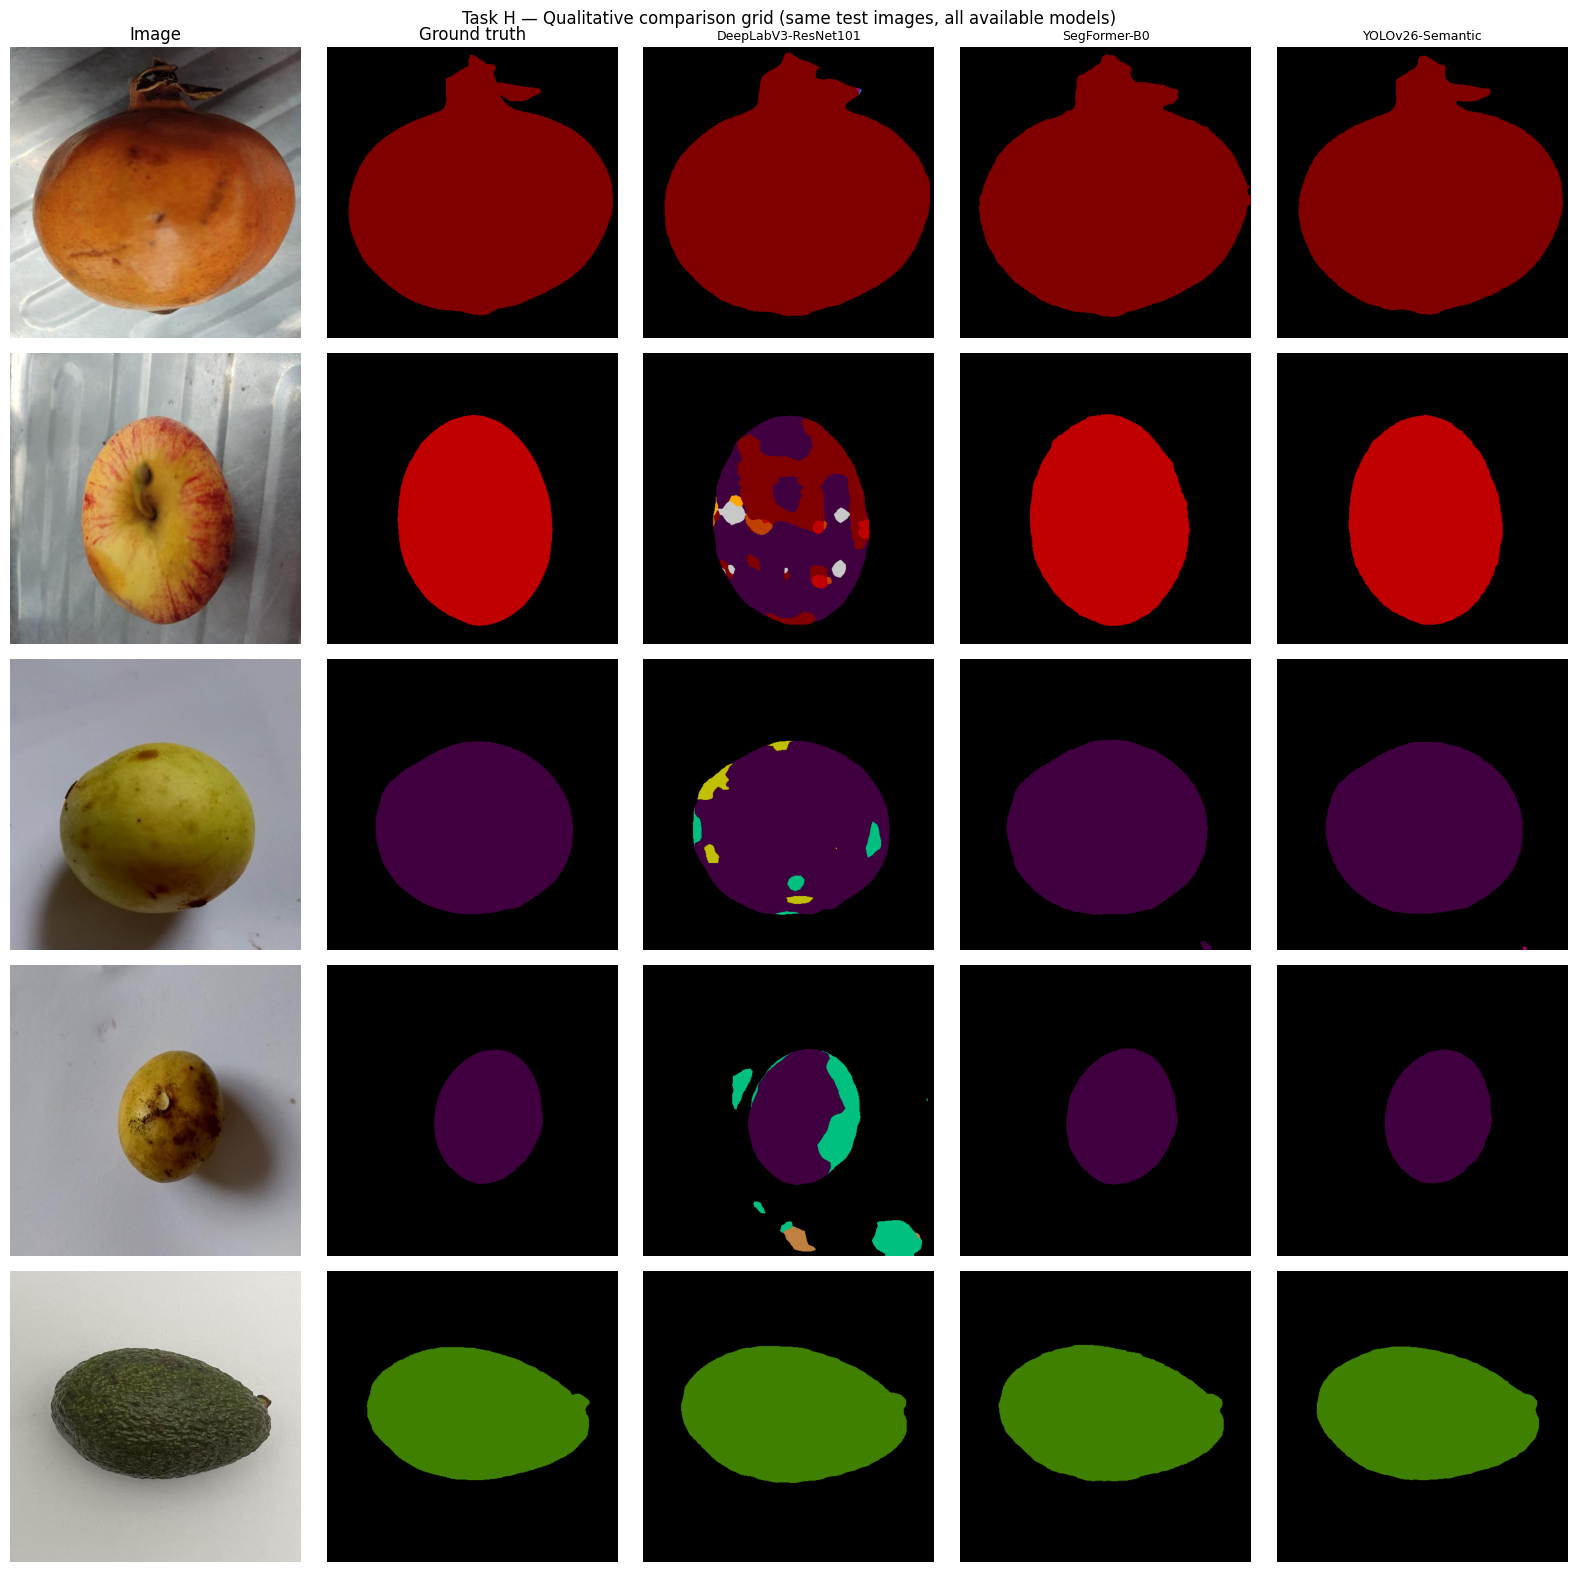

In [5]:
# ── Task H: side-by-side qualitative grids (same test images, all 3 models + GT) ─
# Reads each model's cached predictions from qualitative_cache/<model>/<stem>.png,
# saved by the caching cell added at the end of NB1, NB2, and NB3 respectively.
# All three notebooks sample with the same random_state=42, so the cached stems line
# up across models -- this is what makes it a fair side-by-side comparison.
#
# If NB1/NB2 ran in separate Kaggle sessions, attach their /kaggle/working output as
# a Kaggle dataset input to this notebook (same as already done for results.json above),
# so their qualitative_cache/ folders are reachable here too.
CACHE_ROOTS = {
    'DeepLabV3-ResNet101': [
        Path('/kaggle/working/qualitative_cache/DeepLabV3-ResNet101'),
        Path('/kaggle/input/notebooks/mohuaakter/seg-deeplabv3/qualitative_cache/DeepLabV3-ResNet101'),
    ],
    'SegFormer-B0': [
        Path('/kaggle/working/qualitative_cache/SegFormer-B0'),
        Path('/kaggle/input/notebooks/mohuaakter/seg-segformer-b0/qualitative_cache/SegFormer-B0'),
    ],
    'YOLOv26-Semantic': [
        Path('/kaggle/working/qualitative_cache/YOLOv26-Semantic'),
        Path('/kaggle/input/notebooks/mohuaakter/seg-yolov26-semantic/qualitative_cache/YOLOv26-Semantic'),
    ],
}

def find_cache_dir(candidates):
    for c in candidates:
        if c.exists() and (c / 'stems.json').exists():
            return c
    return None

# GT masks are RGB-colorized (one distinct color per class, per NB0's class_dict.csv),
# NOT pre-stored as small integer class IDs -- must convert before indexing PALETTE.
def rgb_mask_to_index(mask_rgb, palette):
    flat = mask_rgb.reshape(-1, 3).astype(np.int32)
    idx = np.zeros(len(flat), dtype=np.uint8)
    matched = np.zeros(len(flat), dtype=bool)
    for i, color in enumerate(palette):
        eq = np.all(flat == color, axis=1)
        idx[eq] = i
        matched |= eq
    if not matched.all():
        pos = np.where(~matched)[0]
        dists = ((flat[pos][:, None, :] - palette[None, :, :].astype(np.int32)) ** 2).sum(axis=2)
        idx[pos] = dists.argmin(axis=1)
    return idx.reshape(mask_rgb.shape[:2])

cache_dirs = {name: find_cache_dir(paths) for name, paths in CACHE_ROOTS.items()}
missing = [name for name, d in cache_dirs.items() if d is None]
if missing:
    print(f' No cached predictions found for: {missing}. '
          f'Run the caching cell in that model\'s notebook and attach its output '
          f'as a Kaggle dataset input to this notebook, then re-run this cell.')

available_models = [name for name, d in cache_dirs.items() if d is not None]
if not available_models:
    print('No cached predictions available yet -- skipping the qualitative grid.')
else:
    # Use the fixed sample from whichever model has it (they're all the same, seed=42)
    sample_stems = json.loads((cache_dirs[available_models[0]] / 'stems.json').read_text())

    fig, axes = plt.subplots(len(sample_stems), 2 + len(available_models),
                              figsize=(3.2 * (2 + len(available_models)), 3.2 * len(sample_stems)))
    if len(sample_stems) == 1:
        axes = axes[None, :]  # keep 2D indexing consistent for a single-row grid

    stem_to_row = test_df.set_index('stem')
    for row_i, stem in enumerate(sample_stems):
        info = stem_to_row.loc[stem]
        img = Image.open(info.image_path).convert('RGB')
        gt_rgb = np.array(Image.open(info.mask_path).convert('RGB'))
        gt = rgb_mask_to_index(gt_rgb, PALETTE)
        axes[row_i, 0].imshow(img); axes[row_i, 0].axis('off')
        axes[row_i, 1].imshow(PALETTE[gt]); axes[row_i, 1].axis('off')
        if row_i == 0:
            axes[row_i, 0].set_title('Image'); axes[row_i, 1].set_title('Ground truth')

        for col_i, name in enumerate(available_models):
            pred_png = cache_dirs[name] / f'{stem}.png'
            ax = axes[row_i, 2 + col_i]
            if pred_png.exists():
                ax.imshow(Image.open(pred_png))
            else:
                ax.text(0.5, 0.5, 'missing', ha='center', va='center', fontsize=8)
            ax.axis('off')
            if row_i == 0:
                ax.set_title(name, fontsize=9)

    plt.suptitle('Task H — Qualitative comparison grid (same test images, all available models)')
    plt.tight_layout(); plt.show()

### Task H — Written verdict

*(Fill in after a real training run; the template below shows the structure expected.)*

- **Best mIoU:** `<model name>`, mIoU = `<value>` — state whether the margin over the runner-up
  is large enough to be meaningful given the dataset's class imbalance (NB0 Task A) and the
  common failure classes identified across NB1/NB2/NB3 Task G.
- **Most efficient:** compare `Training Time (min)` and per-image inference latency across the
  three models — the transformer encoder (SegFormer-B0) and the CNN+ASPP decoder (DeepLabV3)
  trade off differently between training throughput and single-crop inference speed; YOLOv26
  is typically optimized for the fastest inference of the three.
- **Deployment recommendation:** weigh accuracy vs. speed vs. model size for the target use
  case (e.g., an on-device fruit-sorting camera favors YOLOv26's speed; an offline QA pipeline
  can afford DeepLabV3/SegFormer's likely-higher boundary accuracy).
- **Shared vs. distinct failure modes:** cross-reference each notebook's Task G "most confused
  class pairs" — note which pairs (e.g., same-species cultivars, or classes with the least
  pixel support from NB0 Task A) appear on *all three* lists (architecture-agnostic, dataset-driven
  difficulty) vs. pairs unique to one architecture (inductive-bias-driven difficulty).
